In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json
from collections import Counter

I0000 00:00:1781722488.694910 1714110 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [3]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [4]:
# Normalize the images
all_images = []
all_labels = []

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["label"] == "NonCancer" :
        all_labels.append(0)
    elif meta["label"] == "Unknown" :
        continue
    elif meta["label"] == "IndexCancer" or meta["label"] == "PreIndexCancer" : 
        all_labels.append(1)
    else : 
        continue
    img = np.load(ID)['data']
    img = img.astype("float32") / 255.0 # Normalize to 0-1
    img = np.expand_dims(img, axis=-1)
    all_images.append(img)

In [5]:
# Split data
train_size = int(0.7 * len(all_images))
val_size = int(0.015 * len(all_images))
test_size = int(0.015 * len(all_images))

train_images = all_images[:train_size]
val_images = all_images[train_size:val_size + train_size]
test_images = all_images[val_size + train_size:val_size + train_size + test_size]

train_labels = all_labels[:train_size]
val_labels = all_labels[train_size:val_size + train_size]
test_labels = all_labels[val_size + train_size:val_size + train_size + test_size]

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")

Train: 113112, Val: 2423, Test: 2423
Train: 113112, Val: 2423, Test: 2423


In [6]:
# Convert to NumPy array
train_images = np.array(train_images, dtype=np.float32)
val_images = np.array(val_images, dtype=np.float32)
test_images = np.array(test_images, dtype=np.float32)

train_labels = np.array(train_labels, dtype=np.float32)
val_labels = np.array(val_labels, dtype=np.float32)
test_labels = np.array(test_labels, dtype=np.float32)

print("train", Counter(train_labels.astype(int)))
print("train", Counter(val_labels.astype(int)))
print("train", Counter(test_labels.astype(int)))

train Counter({np.int64(0): 111129, np.int64(1): 1983})
train Counter({np.int64(0): 2349, np.int64(1): 74})
train Counter({np.int64(0): 2353, np.int64(1): 70})


In [7]:
# Create balanced train dataset
images = []
labels = []
NonCancer = 0
Cancer = 0
for img, label in zip(train_images, train_labels) :
    if NonCancer == 1983 and Cancer == 1983 :
        break
    if NonCancer < 1983 and label == 0 :
        images.append(img)
        labels.append(label)
        NonCancer += 1
    elif Cancer < 1983 and label == 1 :
        images.append(img)
        labels.append(label)
        Cancer += 1
train_images = np.array(images, dtype=np.float32)
train_labels = np.array(labels, dtype=np.float32)
print("train", Counter(train_labels.astype(int)))

train Counter({np.int64(0): 1983, np.int64(1): 1983})


In [8]:
# Check the distribution of classes
print(f'Average class probability in training set:   {train_labels.mean():.4f}')
print(f'Average class probability in validation set: {val_labels.mean():.4f}')
print(f'Average class probability in test set:       {test_labels.mean():.4f}')

Average class probability in training set:   0.5000
Average class probability in validation set: 0.0305
Average class probability in test set:       0.0289


In [9]:
# Check dimension size and color channel
print("Shape:", all_images[0].shape)

Shape: (256, 256, 1)


In [10]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.shuffle(len(train_labels)).batch(32)

I0000 00:00:1781722626.940317 1714110 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:bd:00.0, compute capability: 8.0


In [11]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
# Import pretrained model
base_model = tf.keras.applications.EfficientNetB0(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top
                                                 )
# Freeze base model
base_model.trainable = False

In [13]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
# Convert image tensor from 1 channel to 3 for the model
inputs = tf.keras.Input(shape=(256, 256, 1))
x = tf.keras.layers.Lambda(tf.image.grayscale_to_rgb)(inputs)

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)   # ← add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs, outputs) # wrap all layers

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [18]:
initial_epochs = 10
history = model.fit(train_ds, epochs=initial_epochs, validation_data = val_ds)

Epoch 1/10
119/124 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc_pr: 0.2872 - binary_accuracy: 0.9099 - loss: 0.3819 - recall: 0.1655

W0000 00:00:1781722686.641379 1715965 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781722686.641532 1715965 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
E0000 00:00:1781722689.270116 1715965 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781722689.693861 1715965 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781722692.360200 1715965 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781722693.375737 1715965 cuda_timer.cc:87] Delay kernel timed out: measured time has sub

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - auc_pr: 0.3130 - binary_accuracy: 0.9078 - loss: 0.3846 - recall: 0.1877

W0000 00:00:1781722723.079604 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781722723.080918 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
W0000 00:00:1781722727.571061 1715965 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781722727.571263 1715965 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
E0000 00:00:1781722728.741094 1715965 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781722732.837159 1715965 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems

124/124 ━━━━━━━━━━━━━━━━━━━━ 71s 576ms/step - auc_pr: 0.9319 - binary_accuracy: 0.8606 - loss: 0.4421 - recall: 0.7242 - val_auc_pr: 0.0305 - val_binary_accuracy: 0.0305 - val_loss: 4.4288 - val_recall: 1.0000
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - auc_pr: 0.6628 - binary_accuracy: 0.6959 - loss: 0.8906 - recall: 0.6939 - val_auc_pr: 0.0305 - val_binary_accuracy: 0.0305 - val_loss: 4.0819 - val_recall: 1.0000
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - auc_pr: 0.6787 - binary_accuracy: 0.6921 - loss: 0.8677 - recall: 0.6929 - val_auc_pr: 0.0305 - val_binary_accuracy: 0.0305 - val_loss: 3.9828 - val_recall: 1.0000
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - auc_pr: 0.6941 - binary_accuracy: 0.6909 - loss: 0.8582 - recall: 0.6894 - val_auc_pr: 0.0305 - val_binary_accuracy: 0.0305 - val_loss: 3.9490 - val_recall: 1.0000
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - auc_pr: 0.6891 - binary_accuracy: 0.6906 - loss: 0.8568 - recall: 0.6889 - val

In [19]:
# Unfreeze base model for fine tunning
base_model.trainable = True

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 2,564 (10.02 KB)

In [22]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.0),
    ],
)

In [23]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history = model.fit(train_ds, epochs=total_epochs, validation_data = val_ds)

Epoch 1/20


W0000 00:00:1781722975.703378 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781722975.704463 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


123/124 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - binary_accuracy: 0.1582 - loss: 0.3092

W0000 00:00:1781723004.625028 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781723004.625560 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
E0000 00:00:1781723013.578411 1715966 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781723013.983343 1715966 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781723017.851593 1715966 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781723018.777829 1715966 cuda_timer.cc:87] Delay kernel timed out: measured time has sub

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - binary_accuracy: 0.1609 - loss: 0.3105

W0000 00:00:1781723084.018577 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781723084.020096 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert
W0000 00:00:1781723088.461429 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781723088.461644 1715966 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


124/124 ━━━━━━━━━━━━━━━━━━━━ 149s 762ms/step - binary_accuracy: 0.5000 - loss: 0.4642 - val_binary_accuracy: 0.0305 - val_loss: 2.9936
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - binary_accuracy: 0.5000 - loss: 0.8766 - val_binary_accuracy: 0.0305 - val_loss: 1.5211
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - binary_accuracy: 0.5000 - loss: 0.7991 - val_binary_accuracy: 0.0305 - val_loss: 1.1417
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - binary_accuracy: 0.5000 - loss: 0.7969 - val_binary_accuracy: 0.0305 - val_loss: 1.1126
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - binary_accuracy: 0.5000 - loss: 0.7546 - val_binary_accuracy: 0.0305 - val_loss: 1.4712
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - binary_accuracy: 0.5000 - loss: 0.7343 - val_binary_accuracy: 0.9695 - val_loss: 77.5226
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - binary_accuracy: 0.5000 - loss: 0.8549 - val_binary_accuracy: 0.0508 - val_loss: 0.4340
Epoc

In [25]:
predictions = model.predict(test_ds)

73/76 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

W0000 00:00:1781723347.561819 1715965 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_equal_1/Assert/Assert
W0000 00:00:1781723347.563017 1715965 assert_op.cc:39] Ignoring Assert operator functional_1/lambda_1/grayscale_to_rgb/assert_greater_equal/Assert/Assert


76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step


In [26]:
predictions

array([[0.962431  ],
       [0.9604598 ],
       [0.95965904],
       ...,
       [0.9595286 ],
       [0.9590531 ],
       [0.96139866]], shape=(2423, 1), dtype=float32)

In [27]:
print(model.evaluate(x=test_ds))

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.0289 - loss: 3.1450
[3.1449525356292725, 0.02888980694115162]


76/76 - 1s - 12ms/step - binary_accuracy: 0.0289 - loss: 3.1450


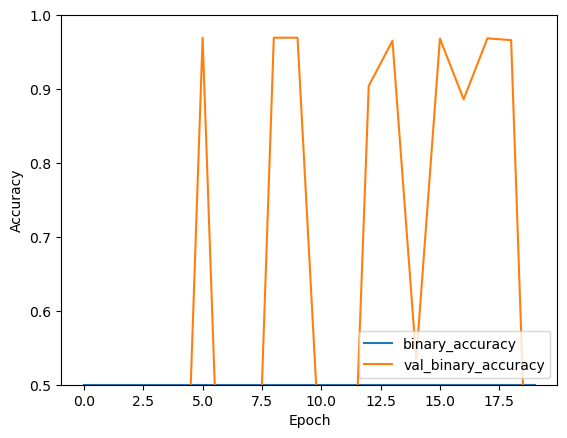

In [29]:
# Evaluate model
plt.plot(history.history['binary_accuracy'], label='binary_accuracy')
plt.plot(history.history['val_binary_accuracy'], label = 'val_binary_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)